In [3]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load the data

In [4]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [23]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [24]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    # ***************************************************
    N = y.shape[0]
    f_x = tx @ w
    
    result = (1/(2*N))*np.sum((y - f_x)**2)
    return result

# 2. Grid Search

Fill in the function `grid_search()` below:

In [25]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss for each combination of w0 and w1.
    # ***************************************************
    N = y.shape[0]
    for i in range(len(grid_w0)):
        for j in range(len(grid_w1)):
            w = np.asarray([grid_w0[i], grid_w1[j]])
            losses[i][j] = compute_loss(y, tx, w)
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=42.424483146781974, w0*=66.66666666666669, w1*=16.666666666666686, execution time=0.004 seconds


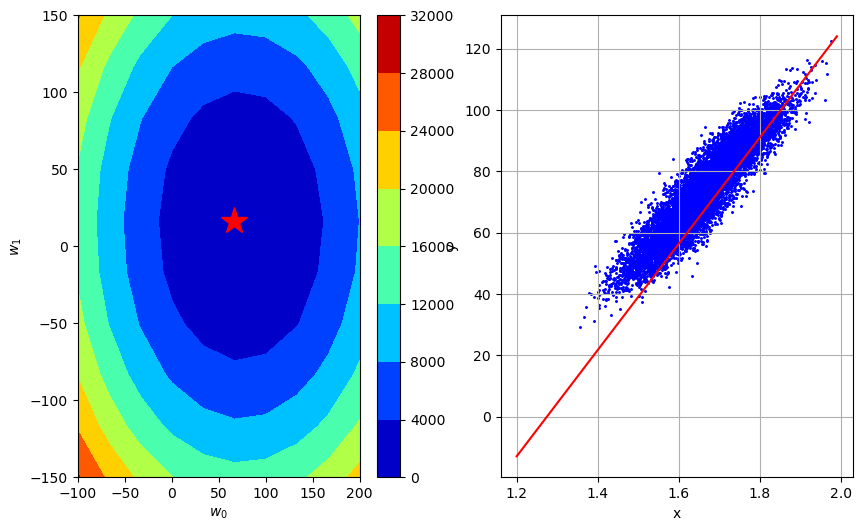

In [26]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=10)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [27]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    N = y.shape[0]
    f_x = tx @ w
    e = y - f_x
    
    return (-1/N)*tx.T @ e

Please fill in the functions `gradient_descent` below:

In [28]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute gradient and loss
        # ***************************************************
        grad = compute_gradient(y, tx, w)
        loss = compute_loss(y, tx, w)
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by gradient
        # ***************************************************
        w = w - gamma * grad

        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [29]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2792.236712759167, w0=51.305745401473594, w1=9.435798704492393
GD iter. 1/49: loss=265.30246210895945, w0=66.69746902191568, w1=12.266538315840098
GD iter. 2/49: loss=37.878379550440975, w0=71.31498610804827, w1=13.115760199244379
GD iter. 3/49: loss=17.41021212017447, w0=72.70024123388806, w1=13.370526764265652
GD iter. 4/49: loss=15.568077051450459, w0=73.11581777164001, w1=13.446956733772032
GD iter. 5/49: loss=15.402284895265295, w0=73.24049073296558, w1=13.469885724623945
GD iter. 6/49: loss=15.38736360120863, w0=73.27789262136326, w1=13.476764421879517
GD iter. 7/49: loss=15.386020684743533, w0=73.28911318788256, w1=13.478828031056189
GD iter. 8/49: loss=15.385899822261674, w0=73.29247935783836, w1=13.47944711380919
GD iter. 9/49: loss=15.385888944638307, w0=73.2934892088251, w1=13.47963283863509
GD iter. 10/49: loss=15.385887965652202, w0=73.29379216412111, w1=13.479688556082861
GD iter. 11/49: loss=15.385887877543452, w0=73.29388305070992, w1=13.479705271317

interactive(children=(IntSlider(value=51, description='n_iter', max=51, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

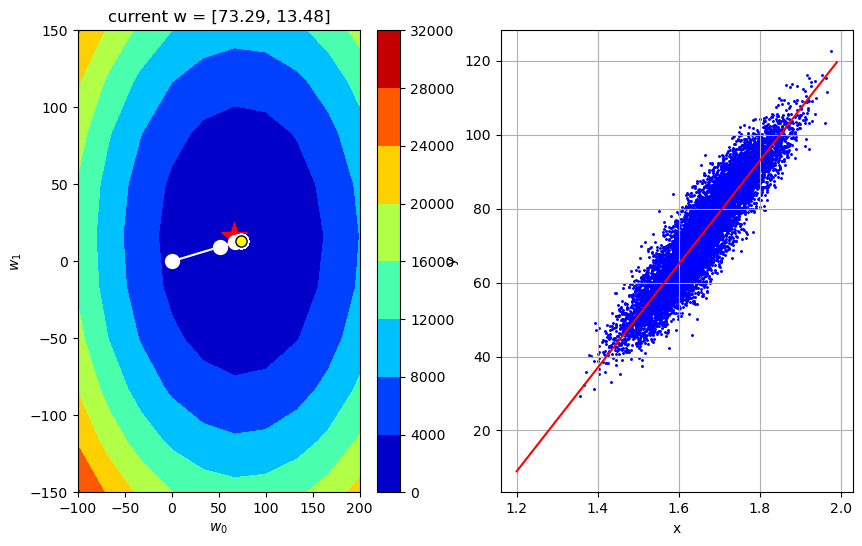

In [30]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    return fig


interact(
    plot_figure,
    n_iter=IntSlider(min=1, max=len(gd_ws), value=len(gd_ws)),
 )

# 4. Stochastic gradient descent

In [31]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: implement stochastic gradient computation. It's the same as the usual gradient.
    # ***************************************************
    f_x = tx @ w
    e = y - f_x
    B = y.shape[0]  # ou len(y)
    
    return (-1 / B) * tx.T @ e


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, )
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic gradient descent.
        # ***************************************************
        indices = np.random.choice(len(y), size=batch_size, replace=False)
        y_batch = y[indices]
        tx_batch = tx[indices]

        grad = compute_stoch_gradient(y_batch, tx_batch, w)
        loss = compute_loss(y_batch, tx_batch, w)

        w = w - gamma*grad

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [32]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=1771.5816370991747, w0=5.952447626143677, w1=-5.907175589614644
SGD iter. 1/49: loss=3471.800051799273, w0=14.285274339569648, w1=5.114777102359643
SGD iter. 2/49: loss=1916.8290619891072, w0=20.47692849979066, w1=14.368774495149072
SGD iter. 3/49: loss=1664.4602321695938, w0=26.24660826936123, w1=14.834180392232433
SGD iter. 4/49: loss=977.4173068916742, w0=30.667959435897707, w1=12.80410548420525
SGD iter. 5/49: loss=928.1283190758312, w0=34.976389124486886, w1=14.051769505798504
SGD iter. 6/49: loss=702.8232720349414, w0=38.72558443024235, w1=12.76417154536664
SGD iter. 7/49: loss=658.7211438155957, w0=42.355243212595305, w1=10.338137640204378
SGD iter. 8/49: loss=604.9472083780859, w0=45.833596870227275, w1=13.165581650084942
SGD iter. 9/49: loss=522.6959376907524, w0=49.066848910173285, w1=8.385675292234927
SGD iter. 10/49: loss=545.697247251295, w0=52.3704749400117, w1=10.948168784905643
SGD iter. 11/49: loss=318.4357576229126, w0=54.89410628243441, w1=8.6108

interactive(children=(IntSlider(value=1, description='n_iter', max=1, min=1), Output()), _dom_classes=('widget…

<function __main__.plot_figure(n_iter)>

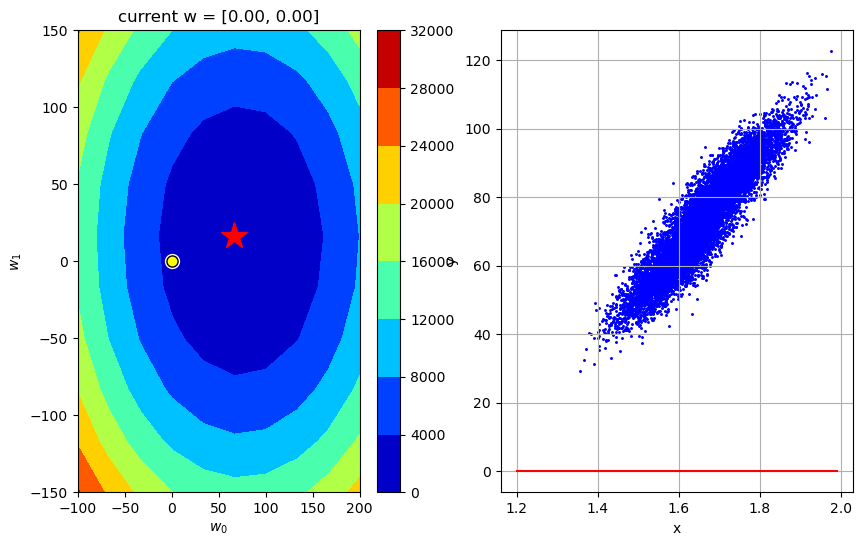

In [33]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    return fig


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

# 5. Effect of Outliers and MAE Cost Function

In [45]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: reload the data by subsampling first, then by subsampling and adding outliers
# ***************************************************
height, weight, gender = load_data(sub_sample=True, add_outlier=True)



x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [46]:
y.shape, tx.shape

((202,), (202, 2))

In [47]:
from grid_search import generate_w, grid_search
from plots import gradient_descent_visualization

# Fit the model and build the loss surface for the current outlier dataset.
grid_w0, grid_w1 = generate_w(num_intervals=100)
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

max_iters = 50
gamma = 0.7
w_initial = np.array([0.0, 0.0])
start_time = datetime.datetime.now()
losses, ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

execution_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=execution_time))

GD iter. 0/49: loss=2869.8351145358524, w0=51.847464098448434, w1=7.724426406192428
GD iter. 1/49: loss=318.2821247015961, w0=67.40170332798299, w1=10.041754328050118
GD iter. 2/49: loss=88.6423556165127, w0=72.06797509684336, w1=10.736952704607411
GD iter. 3/49: loss=67.97477639885521, w0=73.46785662750146, w1=10.945512217574596
GD iter. 4/49: loss=66.11469426926604, w0=73.88782108669889, w1=11.00808007146475
GD iter. 5/49: loss=65.94728687760303, w0=74.01381042445813, w1=11.026850427631796
GD iter. 6/49: loss=65.93222021235334, w0=74.0516072257859, w1=11.032481534481912
GD iter. 7/49: loss=65.93086421248087, w0=74.06294626618423, w1=11.034170866536945
GD iter. 8/49: loss=65.93074217249234, w0=74.06634797830372, w1=11.034677666153454
GD iter. 9/49: loss=65.93073118889338, w0=74.06736849193958, w1=11.034829706038407
GD iter. 10/49: loss=65.93073020036948, w0=74.06767464603033, w1=11.034875318003893
GD iter. 11/49: loss=65.93073011140231, w0=74.06776649225755, w1=11.03488900159354
GD it

interactive(children=(IntSlider(value=51, description='n_iter', max=51, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

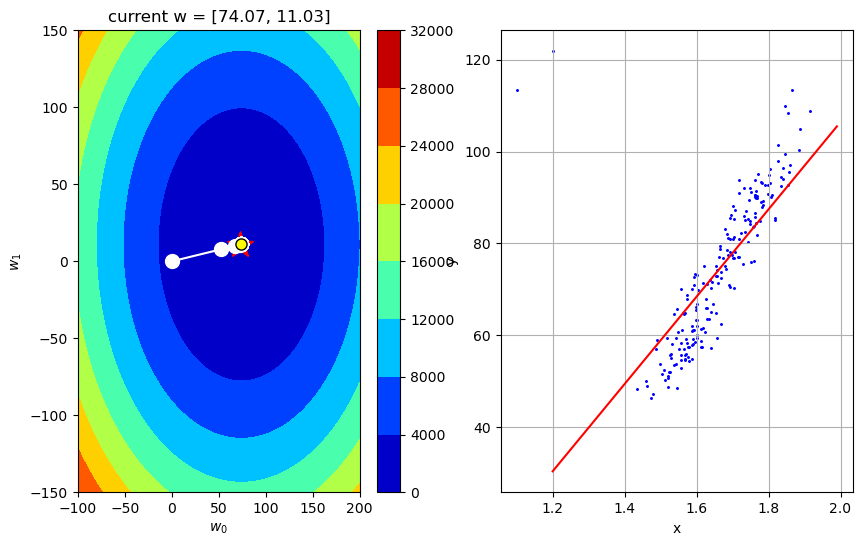

In [48]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        losses,
        ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    return fig


interact(
    plot_figure,
    n_iter=IntSlider(min=1, max=len(ws), value=len(ws)),
 )

# 6. Subgradient descent

In [6]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    N = y.shape[0]
    return -(tx.T @ np.sign(y - tx @ w)) / N

In [5]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    # ***************************************************
    N = y.shape[0]
    f_x = tx @ w
    return np.sum(np.abs((y - f_x)))
    
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute subgradient and loss
        # ***************************************************
        subgrad = compute_subgradient_mae(y, tx, w)
        loss =  compute_loss(y, tx, w)
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by subgradient
        # ***************************************************
        w = w - gamma*subgrad

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [59]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=14961.696782695128, w0=0.7, w1=6.109524327590712e-16
SubGD iter. 1/499: loss=14820.296782695128, w0=1.4, w1=1.2219048655181425e-15
SubGD iter. 2/499: loss=14678.896782695127, w0=2.0999999999999996, w1=1.832857298277214e-15
SubGD iter. 3/499: loss=14537.496782695129, w0=2.8, w1=2.443809731036285e-15
SubGD iter. 4/499: loss=14396.096782695127, w0=3.5, w1=3.054762163795356e-15
SubGD iter. 5/499: loss=14254.69678269513, w0=4.2, w1=3.665714596554428e-15
SubGD iter. 6/499: loss=14113.296782695128, w0=4.9, w1=4.276667029313499e-15
SubGD iter. 7/499: loss=13971.896782695128, w0=5.6000000000000005, w1=4.887619462072571e-15
SubGD iter. 8/499: loss=13830.496782695127, w0=6.300000000000001, w1=5.498571894831642e-15
SubGD iter. 9/499: loss=13689.096782695127, w0=7.000000000000001, w1=6.109524327590714e-15
SubGD iter. 10/499: loss=13547.69678269513, w0=7.700000000000001, w1=6.720476760349785e-15
SubGD iter. 11/499: loss=13406.296782695128, w0=8.4, w1=7.331429193108857e-15
Sub

interactive(children=(IntSlider(value=51, description='n_iter', max=51, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

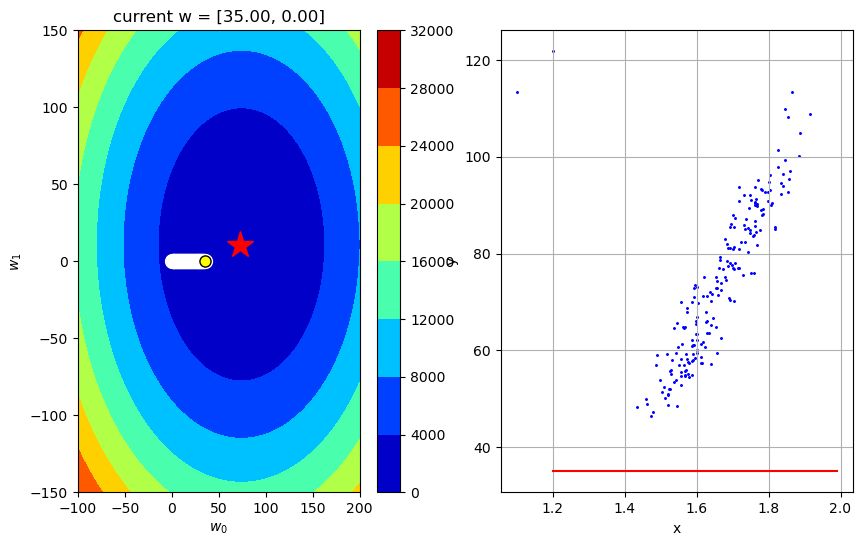

In [61]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(
    plot_figure,
    n_iter=IntSlider(min=1, max=len(ws), value=len(ws)),
 )

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [1]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic subgradient of the loss at w.
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by subgradient
        # ***************************************************
        indices = np.random.randint(0, y.shape[0], batch_size)
        tx_subsampled = tx[indices]
        y_subsampled = y[indices]

        subgrad = compute_subgradient_mae(y_subsampled, tx_subsampled, w)
        loss = compute_loss(y_subsampled, tx_subsampled, w)

        w = w - gamma * subgrad
        losses.append(loss)
        ws.append(w)

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [7]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=50.41599734999985, w0=0.7, w1=-1.1203792552991434
SubSGD iter. 1/499: loss=84.37409224961283, w0=1.4, w1=-0.7198476003985654
SubSGD iter. 2/499: loss=57.44762888911535, w0=2.0999999999999996, w1=-1.2738142976570943
SubSGD iter. 3/499: loss=74.6263761650766, w0=2.8, w1=-1.2989771160965915
SubSGD iter. 4/499: loss=56.877993714415446, w0=3.5, w1=-1.7494738832381609
SubSGD iter. 5/499: loss=72.36120944770768, w0=4.2, w1=-1.8568420668038599
SubSGD iter. 6/499: loss=60.77288756408948, w0=4.9, w1=-2.2028282579492036
SubSGD iter. 7/499: loss=85.24573468521635, w0=5.6000000000000005, w1=-1.6170191727744876
SubSGD iter. 8/499: loss=35.98534183157496, w0=6.300000000000001, w1=-2.9832668237442608
SubSGD iter. 9/499: loss=62.64837172467196, w0=7.000000000000001, w1=-2.879441083105659
SubSGD iter. 10/499: loss=60.720332978082816, w0=7.700000000000001, w1=-3.1317447232586506
SubSGD iter. 11/499: loss=79.7566074607158, w0=8.4, w1=-2.6074813686597222
SubSGD iter. 12/499: loss=7

interactive(children=(IntSlider(value=1, description='n_iter', max=1, min=1), Output()), _dom_classes=('widget…

<function __main__.plot_figure(n_iter)>

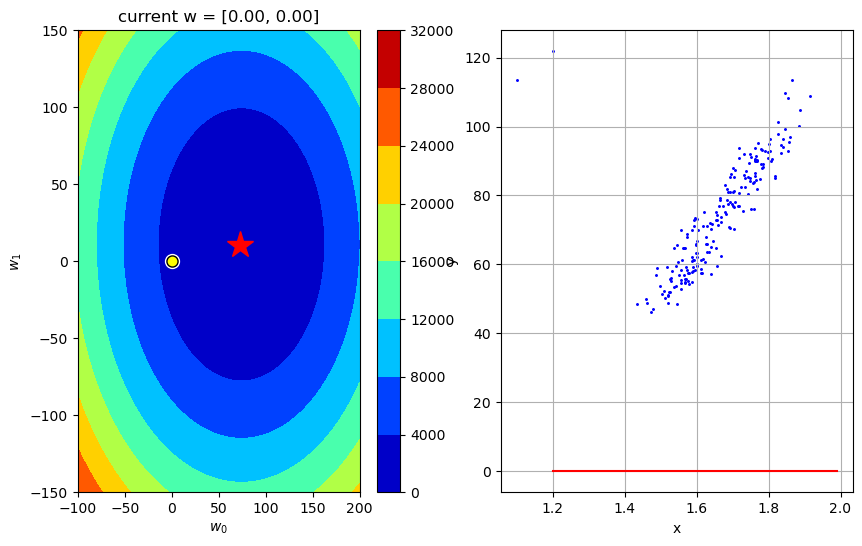

In [66]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(
    plot_figure,
    n_iter=IntSlider(min=1, max=len(subsgd_ws), value=len(subsgd_ws)),
 )